In [2]:
import pandas as pd
import datetime as dt 
from datetime import date
import pyperclip as pyp
import pathlib as plb
import matplotlib.pyplot as plt
import seaborn as sb
import pandas.api.types as typ


# <span style="color: rgb(0, 230, 222, 0.89);">  **NIVEL 1** </span>
### <span style="color: rgba(0, 230, 222, 0.89);">  **N-1.1** </span>
- Importamos el arichivo y lo convertimos en Data Frame     
- Ordenamos el DataFrame por el país de origen y por ciudad en caso de empate.
- Mostramos las primeras 10 filas.
- Realizamos un print que compruebe que el DNI tiene valores únicos

In [3]:
################## S10 N-1
############ N-1.1

df_trabajadores = pd.read_excel(r"C:\Users\Usuario\Downloads\sprint10.xlsx",
                              header=3)
df_trabajadores = df_trabajadores.sort_values(["País d'origen","Ciutat"],ascending=True)
if df_trabajadores["DNI"].is_unique:
    print("Todos los DNIs son únicos")
else:
    print("Hay DNIs duplicados")
df_trabajadores.head(10)

Todos los DNIs son únicos


,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


### <span style="color: rgba(0, 230, 222, 0.89);"> **N-1.2 / N-1.2 / N-1.3 / N-1.4**</span>
- Creamos una columna que sea el nombre completo.
- Creamos una columna si la persona ha nacido en España o no.
- Ponemos el DNI como índice del DataFrame (numero de filas).
- Sustituimos el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.
- Sustituimos a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (nan/null/na).
- Juntamos las tablas fill y no fill en una.
- Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. 
- Creamos una función que dada una fecha calcula la edad actual a día de hoy, y lo ponemoso una nueva columna.
- Mostramos todos los cambios realizados.

In [4]:
############ N-1.2 / N-1.2 
############ N-1.3 / N-1.4  

df_trabajadores["Nom complet"] = df_trabajadores["Nom"].str.cat(
                        others=df_trabajadores["Cognoms"],sep=" ")

def nacido_en_españa(pais_de_origen):
    if pais_de_origen == "Espanya":
        return "Si"
    else:
        return "No"
df_trabajadores["Nascut a Espanya"] = df_trabajadores["País d'origen"].apply(
                                                            nacido_en_españa)

df_trabajadores = df_trabajadores.set_index("DNI", drop=False)

df_trabajadores = df_trabajadores.rename(columns= {"Any de Naixement":"Any"})
df_trabajadores = df_trabajadores.rename(columns= {"Mes de Naixement":"Mes"})
df_trabajadores = df_trabajadores.rename(columns= {"Dia de Naixement":"Dia"})

def cambio_genero(genero):
    if genero == "D":
        return "Dona"
    elif genero == "H":
        return "Home"
    elif genero == "A":
        return "Altres"
    else:
        return "Na"
df_trabajadores["Gènere"] = df_trabajadores["Gènere"].apply(cambio_genero)

df_trabajadores["Fills"] = df_trabajadores["Fills"].astype(str)
df_trabajadores["No Fills"] = df_trabajadores["No Fills"].astype(str)
df_trabajadores = df_trabajadores.rename(columns= {"Fills":"Si Fills"})
def tiene_hijos(hijos):
    if hijos == "1.0":
        return "Si"
    else:
        return ""
def no_tiene_hijos(hijos):
    if hijos == "1.0":
        return "No"
    else:
        return ""
df_trabajadores["Si Fills"] = df_trabajadores["Si Fills"].apply(tiene_hijos)
df_trabajadores["No Fills"] = df_trabajadores["No Fills"].apply(no_tiene_hijos)
df_trabajadores["Fills"] = df_trabajadores["Si Fills"].str.cat(
                                            others=df_trabajadores["No Fills"])

df_trabajadores = df_trabajadores.drop(["Unnamed: 0","No Fills","Si Fills"],axis=1)

df_trabajadores = df_trabajadores.rename(columns={"Dia":"day",
                                                  "Mes":"month",
                                                  "Any":"year"})
df_trabajadores["Fecha de naciment"] = pd.to_datetime(df_trabajadores[[
                                                    "day","month","year"]])
# - en caso de que se requiera calular las horas, lo quitamos. 
df_trabajadores = df_trabajadores.rename(columns={"day":"Dia",
                                                  "month":"Mes",
                                                  "year":"Any"})
def calculadora_edad(fecha_nacimiento):
    hoy = date.today()
    edad = hoy.year - fecha_nacimiento.year 
    if (hoy.month,hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day):
        edad -=1 
    return edad
df_trabajadores["Edad"] = df_trabajadores["Fecha de naciment"].apply(
                                                    calculadora_edad)
df_trabajadores

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Grup Professional,Nom complet,Nascut a Espanya,Fills,Fecha de naciment,Edad
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,Altres,951 €,Grup A,Mia Schneider Fischer,No,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Grup B,Laura Schneider Fischer,No,Si,1958-02-02,68
37368317L,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,Dona,2.013 €,Grup B,Lea Schneider Schneider,No,No,2005-10-23,20
21390098Z,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Grup B,Mia Fischer,No,Si,1950-08-11,75
44060014R,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,Home,2.754 €,Grup D,Jonas Schneider,No,Si,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,Grup B,Emily Taylor Jones,No,No,1958-03-28,68
57441590Y,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Grup A,George Brown Jones,No,Si,1979-12-27,46
58204038A,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,Grup A,Olivia Brown Brown,No,No,1952-08-28,73


### <span style="color: rgba(0, 230, 222, 0.89);"> **N-1.5**</span>
- Creamos una tabla resumen que permite ver el salario medio por género y país de origen.
- Añadimos las medias a los márgenes de la tabla.

In [5]:
############ N-1.5

df_trabajadores["Salari mensual"] = (df_trabajadores["Salari mensual"].str.replace("€","")
                                                                     .str.replace(".","")).astype(int)
tabla_salarios_medio = pd.crosstab(df_trabajadores["Gènere"], df_trabajadores["País d'origen"], df_trabajadores["Salari mensual"], aggfunc= "mean")
tabla_salarios_medio_margenes = pd.crosstab(df_trabajadores["Gènere"], df_trabajadores["País d'origen"], df_trabajadores["Salari mensual"], aggfunc= "mean", margins=True).round(1)
tabla_salarios_medio_margenes


País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.0,1141.0,1030.0,1706.2,NaN,1423.0,1365.0,1372.0,1765.0,1921.0,1626.6
Dona,1804.3,1291.8,1497.8,1460.2,1566.5,1247.2,1405.2,1517.8,1488.5,1489.5,1469.4
Home,2067.4,1583.3,1554.7,1682.1,1389.2,1672.9,1531.0,1625.0,1497.0,1162.6,1643.2
Na,1931.5,1135.7,1252.0,1597.1,1573.0,1316.0,1365.5,1583.0,1553.5,1758.0,1568.9
All,1858.3,1431.7,1489.1,1582.2,1465.4,1421.2,1441.7,1559.1,1527.2,1448.3,1561.5


- Creamos un mapa de calor que nos muestra los salarios medios más altos por pais y genero.

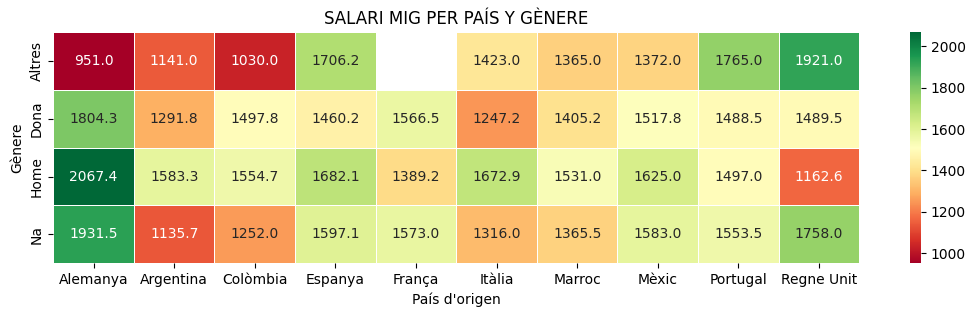

In [6]:
plt.figure(figsize=(13,3))
plt.title("SALARI MIG PER PAÍS Y GÈNERE")
sb.heatmap(tabla_salarios_medio, cmap="RdYlGn",annot=True, fmt=".1f", linewidths=0.4)
plt.show()

### <span style="color: rgba(0, 230, 222, 0.89);"> **N-1.6**</span>
- Creamos una tabla resumen que permite ver el sueldo medio, mínimo y máximo por Género y país de origen.
- Para ello realizamos unos cambio para poder hacer los calculos.
- Ordena la tabla en función del sueldo medio.

In [7]:
############ N-1.6

tabla_salarios_genero = pd.DataFrame()
tabla_salarios_genero = df_trabajadores.groupby("Gènere",as_index=False).agg(
                                        salari_mig=("Salari mensual","mean"),
                                        salari_minim=("Salari mensual","min"),
                                        salari_maxim=("Salari mensual","max")).round(2)
tabla_salarios_genero = tabla_salarios_genero.rename(columns={"salari_mig":"Salari mig",
                                                              "salari_minim":"Salari minim",
                                                              "salari_maxim":"Salari maxim"})
tabla_salarios_genero = tabla_salarios_genero.sort_values("Salari mig",ignore_index=True,ascending=False)
tabla_salarios_genero

,Gènere,Salari mig,Salari minim,Salari maxim
0,Home,1643.25,737,3356
1,Altres,1626.59,703,3175
2,Na,1568.87,758,2969
3,Dona,1469.44,665,3021


# <span style="color: rgba(0, 230, 222, 0.89);">  **NIVEL 2** </span>
### <span style="color: rgba(0, 230, 222, 0.89);">  **N-2.1** </span>
- Utilizando df_incremento, adjuntamos la columna "Increment" a df_trabajadores.
- Actualizamos la columna "Salari mensual" en función de los porcentajes que se adjuntan.

In [ ]:
################## S10 N-2
############ N-2.1

df_incremento = pd.DataFrame({"Grup Professional":["Grup A","Grup B","Grup C", "Grup D" ],
                             "Increment":[0.05,0.035,0.02,0.08]})
# Hacemos un merege de las dos dfs
df_trabajadores = df_trabajadores.merge(df_incremento,on="Grup Professional",how="left")
df_trabajadores["Salari Actualizat"] = (df_trabajadores["Salari mensual"] * 
                                        (1 + df_trabajadores["Increment"])).round(2)
# Limpiamos y ordenamos el df
df_trabajadores = df_trabajadores.drop(["Dia","Mes","Any","Nom","Cognoms"],axis=1)
df_trabajadores = df_trabajadores[["DNI","Nom complet","País d'origen","Ciutat","Gènere","Salari mensual",
                       "Grup Professional","Nascut a Espanya","Fills","Fecha de naciment","Edad",
                       "Increment","Salari Actualizat" ]]
df_trabajadores

,DNI,Nom complet,País d'origen,Ciutat,Gènere,Salari mensual,Grup Professional,Nascut a Espanya,Fills,Fecha de naciment,Edad,Increment,Salari Actualizat
0,28973553Z,Mia Schneider Fischer,Alemanya,Berlín,Altres,951,Grup A,No,No,1976-10-22,49,0.050,998.55
1,37399141L,Laura Schneider Fischer,Alemanya,Berlín,Dona,1769,Grup B,No,Si,1958-02-02,68,0.035,1830.92
2,37368317L,Lea Schneider Schneider,Alemanya,Berlín,Dona,2013,Grup B,No,No,2005-10-23,20,0.035,2083.46
3,21390098Z,Mia Fischer,Alemanya,Berlín,Dona,1557,Grup B,No,Si,1950-08-11,75,0.035,1611.50
4,44060014R,Jonas Schneider,Alemanya,Berlín,Home,2754,Grup D,No,Si,1985-11-22,40,0.080,2974.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,89577876S,Emily Taylor Jones,Regne Unit,Manchester,Dona,2033,Grup B,No,No,1958-03-28,68,0.035,2104.15
996,57441590Y,George Brown Jones,Regne Unit,Manchester,Home,1130,Grup A,No,Si,1979-12-27,46,0.050,1186.50
997,58204038A,Olivia Brown Brown,Regne Unit,Manchester,Altres,1023,Grup A,No,No,1952-08-28,73,0.050,1074.15
998,28367234K,Isla Jones Brown,Regne Unit,Manchester,Dona,1197,Grup A,No,No,1999-03-28,27,0.050,1256.85


### <span style="color: rgba(0, 230, 222, 0.89);">  **N-2.2**</span>
- Utilizando un bucle, exportamos en 4 archivos en formato .xlsx los datos de cada Grupo Profesional.
- Exporta un 5º DataFrame en formato .xlsx que contiene cuántos trabajadores hay por cada 
  Grupo Profesional, su sueldo medio y edad media.

In [9]:
############ N-2.2

ruta_ficheros = []
for x in df_trabajadores["Grup Professional"].unique(): 
    grupo = df_trabajadores[df_trabajadores["Grup Professional"] == x] 
    grupo.to_excel(f"{x}.xlsx", index=False)
    ruta_ficheros.append(plb.Path(f"{x}.xlsx").resolve())
    pyp.copy(str(ruta_ficheros))


grupos_profesionales = pd.DataFrame()
grupos_profesionales = df_trabajadores.groupby("Grup Professional",as_index=True).agg(
                                                     num_trabajadores=("DNI","count"),
                                                     salario_medio=("Salari mensual","mean"),
                                                     edad_media=("Edad","mean")).round(2)
grupos_profesionales = grupos_profesionales.rename(columns={
                                                  "num_trabajadores":"Nombre de treballdors",
                                                  "salario_medio":"Salari mig",
                                                  "edad_media":"Edad mig"})
grupos_profesionales.to_excel("groupos profesionales.xlsx",index=True)
ruta_fichero = plb.Path("groupos profesionales.xlsx").resolve()
pyp.copy(str(ruta_fichero))
print(f"""- Las rutas de ficheros son las siguiente: 
  {ruta_ficheros} 
  {ruta_fichero}""")

- Las rutas de ficheros son las siguiente: 
  [WindowsPath('C:/Users/Usuario/OneDrive/Documentos/IT ACADEMY/SPRINT 10/Grup A.xlsx'), WindowsPath('C:/Users/Usuario/OneDrive/Documentos/IT ACADEMY/SPRINT 10/Grup B.xlsx'), WindowsPath('C:/Users/Usuario/OneDrive/Documentos/IT ACADEMY/SPRINT 10/Grup D.xlsx'), WindowsPath('C:/Users/Usuario/OneDrive/Documentos/IT ACADEMY/SPRINT 10/Grup C.xlsx')] 
  C:\Users\Usuario\OneDrive\Documentos\IT ACADEMY\SPRINT 10\groupos profesionales.xlsx


# <span style="color: rgba(0, 230, 222, 0.89);">  **NIVEL 3** </span>
### <span style="color: rgba(0, 230, 222, 0.89);">  **N-3.1** </span>
- Creamos una función que tome un dataframe como parámetro de entrada, que crear y exportar un gráfico automáticamente para cada columna del dataframe.
- un histograma para la variable numérica
- unas barras de los valores más frecuentes para la categórica
- unas barras de los años más frecuentes para el formato fecha.
- Muestramos el resultado de la función en el datasets "penguins" que contiene el paquete seaborn.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sb
import pandas.api.types as typ
import os as os 
import numpy as np

In [11]:
# Cargamos del Data Frame de "penguins"
df_penguins = sb.load_dataset("penguins")

# Creamos una funcion clasificadora 
def tipo_var(serie):
        """ Sirve para saber el tipo de 
        dato de cada columna de un Data Frame"""
        if typ.is_numeric_dtype(serie):
            return "numerica"
        elif isinstance(serie,pd.CategoricalDtype) or serie.dtype == object:
            return "categorica"
        elif typ.is_datetime64_any_dtype(serie):
            return "fecha"

# Creamos la funcion que nos genera y exporta los graficos.
def creador_de_graficos(df,carpeta):

    if not os.path.exists(carpeta):
        os.makedirs(carpeta)

    for col in df:
        plt.figure(figsize=(6,3))
        tipo = tipo_var(df[col])
        if tipo == "numerica":
            plt.title(f" Grafic of {col}")
            sb.histplot(df[col])
        elif tipo == "categorica":
            plt.title(f"Grafico of {col}")
            serie_cat = df[col].value_counts().sort_values(ascending=False)
            if len(serie_cat) > 5:
                serie_cat = serie_cat[:5]
            sb.barplot(serie_cat)
        elif tipo == "fecha":
            plt.title(f"Grafic of {col}")
            serie_fecha = df[col].dt.year.value_counts().sort_values(ascending=False)
            if len(serie_fecha)> 5:
                serie_fecha= serie_fecha[:5]
            sb.barplot(serie_fecha)
        plt.tight_layout()
        file_path = os.path.join(carpeta,f"columna de {col}.png")
        plt.savefig(file_path)
        plt.close()
        print(f"Grafico guradado en {file_path}")

creador_de_graficos(df_penguins, "Graficos")


Grafico guradado en Graficos\columna de species.png
Grafico guradado en Graficos\columna de island.png
Grafico guradado en Graficos\columna de bill_length_mm.png
Grafico guradado en Graficos\columna de bill_depth_mm.png
Grafico guradado en Graficos\columna de flipper_length_mm.png
Grafico guradado en Graficos\columna de body_mass_g.png
Grafico guradado en Graficos\columna de sex.png


### <span style="color: rgba(0, 230, 222, 0.89);">  **N-3.2** </span>
- Hacer una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas
- devolviendo una lista con el orden de visita y también la distancia total recorrida.

In [44]:
df_dist_ciudad = pd.read_excel(r"C:\Users\Usuario\Downloads\matriu_distancies.xlsx")
# Cambiamos el el indice y el nombre del mismo
df_dist_ciudad = df_dist_ciudad.rename(columns={"Unnamed: 0":"Ciudad"})
df_dist_ciudad = df_dist_ciudad.set_index("Ciudad")
# Eliminamos las ciudades "Las Palmas de Gran Canaria" y "Palma"
df_dist_ciudad.drop(columns=["Las Palmas de Gran Canaria","Palma"],index=["Las Palmas de Gran Canaria","Palma"],inplace=True)
# Cambiamos la filas celdas Nan por inf
df_dist_ciudad.fillna(np.inf, inplace=True)
df_dist_ciudad

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Ciudad,,,,,,,,,,,,,
Barcelona,inf,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,inf,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,inf,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,inf,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,inf,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,inf,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,inf,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,inf,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,inf,419.0,589.0,634.0,704.0


In [104]:
def caluculador_ruta(df_dist_ciudad, ciudad):
    
    ruta = [ciudad]
    distancia_total = 0
    ciudad_actual = ciudad
    visitadas = {ciudad}

    while len(df_dist_ciudad.index) > len(visitadas):
        dist_min = np.inf
        ciudad_destino = None
        fila_ciudad_actual = df_dist_ciudad.loc[ciudad_actual]
        for x in fila_ciudad_actual.index:
            if x not in visitadas:
                dist = fila_ciudad_actual.loc[x]
                if dist < dist_min:
                    dist_min = dist 
                    ciudad_destino = x

        ruta.append(ciudad_destino)
        distancia_total += dist_min
        visitadas.add(ciudad_destino)
        ciudad_actual = ciudad_destino

    return ruta, distancia_total

caluculador_ruta(df_dist_ciudad,"Barcelona")


(['Barcelona',
  'Hospitalet de Llobregat',
  'Zaragoza',
  'Valencia',
  'Alicante',
  'Murcia',
  'Córdoba',
  'Sevilla',
  'Málaga',
  'Valladolid',
  'Gijón',
  'Bilbao',
  'Vigo'],
 np.float64(2778.0))

- Desde qué ciudad la ruta sería más corta con el algoritmo planteado



In [110]:
def recorrido_mas_corto(df_dist_ciudad):

    lista_rutas = []
    dist_mas_corta = np.inf

    for ciudad in df_dist_ciudad.index:
        lista_rutas.append(caluculador_ruta(df_dist_ciudad,ciudad))

    for ruta in lista_rutas:
        if ruta[1] < dist_mas_corta:
            dist_mas_corta = ruta[1]
            ciudad_inicio = ruta[0][0]
    
    return ciudad_inicio, dist_mas_corta

ciudad, distancia = recorrido_mas_corto(df_dist_ciudad)
print(f"Desde {ciudad} se realiza el recorrido mas corto con una distancia total de {distancia}")

Desde Barcelona se realiza el recorrido mas corto con una distancia total de 2778.0
